<a href="https://colab.research.google.com/github/Kai-Zen23/Elective-1/blob/master/CS412_Lab2_Adaptive_Coding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# CS412 Laboratory 2: From User Preferences to an Adaptive Coding Environment

Reahlyn Ermita,
Jay Mark Labial,
Jim Margaja,
Jake Quejada,
Jude Rabaya

**Dataset:** JetBrains State of Developer Ecosystem 2025, raw data (n = 24,534)
https://devecosystem-2025.jetbrains.com/


## Investigate: load the cleaned data

In [14]:
# Upload the cleaned Excel file (skip the upload if it is already in the Colab files panel)
import os
FILE = "developer_ecosystem_2025_Clean_Data.xlsx"
if not os.path.exists(FILE):
    from google.colab import files
    uploaded = files.upload()
    FILE = list(uploaded.keys())[0]
print("Using file:", FILE)

Saving developer_ecosystem_2025_Clean_Data_fixed.xlsx to developer_ecosystem_2025_Clean_Data_fixed (2).xlsx
Using file: developer_ecosystem_2025_Clean_Data_fixed (2).xlsx


In [15]:
import pandas as pd
pd.set_option("display.max_colwidth", 80)

xls = pd.ExcelFile(FILE)
sheet = next(s for s in xls.sheet_names if s.lower().replace(" ", "_") == "clean_data")
df = pd.read_excel(xls, sheet)

# Experience groups (recomputed from code_yrs so the notebook does not depend on Excel formulas)
GROUP_MAP = {
    "I don't have professional coding experience": "Beginner",
    "Less than 1 year": "Beginner",
    "1–2 years": "Beginner",
    "3–5 years": "Intermediate",
    "6–10 years": "Intermediate",
    "11–15 years": "Experienced",
    "16+ years": "Experienced",
}
GROUPS = ["Beginner", "Intermediate", "Experienced"]
df["experience_group"] = df["code_yrs"].map(GROUP_MAP)

print("Rows:", len(df), "| Columns:", len(df.columns))
sizes = df["experience_group"].value_counts().reindex(GROUPS)
display(pd.DataFrame({"Respondents": sizes, "% of total": (100 * sizes / sizes.sum()).round(1)}))

Rows: 24534 | Columns: 23


,Respondents,% of total
experience_group,,
Beginner,5836,23.8
Intermediate,10482,42.7
Experienced,8216,33.5


##Analyze: differences between user groups

Each table shows the % of each experience group. The last column is **Beginner − Experienced**.
Blank answers are excluded per question (many AI questions were shown only to AI users).

In [16]:
FREQUENT = ["Every day", "Several times a week"]

def share(col, value, among=None):
    """% of each group whose answer in `col` equals `value` (blanks excluded)."""
    out = {}
    for g in GROUPS:
        d = df[df["experience_group"] == g]
        if among is not None:
            d = d[among(d)]
        d = d[d[col].notna()]
        hit = d[col].isin(value) if isinstance(value, list) else (d[col] == value)
        out[g] = round(100 * hit.mean(), 1)
    return out

def make_table(rows):
    t = pd.DataFrame({label: vals for label, vals in rows}).T[GROUPS]
    t["Beg − Exp"] = (t["Beginner"] - t["Experienced"]).round(1)
    return t

ai_users = lambda d: d["uses_ai_tools"] == "Yes"

TABLES = {
  "Table 1. Main IDE / editor (%)": make_table(
      [(ide, share("ide_main", ide)) for ide in ["Visual Studio Code", "IntelliJ IDEA", "PyCharm", "Rider", "Visual Studio"]]),
  "Table 2. Main programming language (%)": make_table(
      [(lang, share("main_lang", lang)) for lang in ["Python", "Java", "JavaScript", "TypeScript", "C#"]]),
  "Table 3. AI tools regularly used (% of AI tool users)": make_table(
      [(t, share(f"ai_tool_{t}", "Yes", among=ai_users)) for t in ["ChatGPT", "GitHub Copilot", "JetBrains AI Assistant", "Cursor", "Claude", "Gemini"]]),
  "Table 4. Uses AI for the task daily or several times a week (%)": make_table([
      ("Code completion",   share("ai_task_freq: Code completion", FREQUENT)),
      ("Generating code",   share("ai_task_freq: Generating code", FREQUENT)),
      ("Explaining code",   share("ai_task_freq: Explaining code", FREQUENT)),
      ("Debugging code",    share("ai_task_freq: Debugging code", FREQUENT)),
      ("Explaining bugs / fixes", share("ai_task_freq: Explaining bugs and offering fixes for them", FREQUENT)),
      ("Learning new things",     share("ai_task_freq: Learning new things about coding and software development", FREQUENT))]),
  "Table 5. Rates the AI feature \"Very important\" (%)": make_table([
      ("Quality of code completion", share("ai_importance: Quality of code completion suggestions", "Very important")),
      ("Quality of chat answers",    share("ai_importance: Quality of answers in chat", "Very important")),
      ("Easy-to-use interface",      share("ai_importance: Easy-to-use user interface", "Very important")),
      ("Smooth IDE integration",     share("ai_importance: Smooth integration with my IDE or code editor", "Very important"))]),
  "Table 6. Employment status (%)": make_table(
      [(s, share("employment_status", s)) for s in ["Student", "Employed full-time"]]),
}

for title, table in TABLES.items():
    print("\n" + title)
    display(table)


Table 1. Main IDE / editor (%)


,Beginner,Intermediate,Experienced,Beg − Exp
Visual Studio Code,32.0,20.3,13.5,18.5
IntelliJ IDEA,20.4,25.8,29.4,-9.0
PyCharm,9.5,9.1,7.6,1.9
Rider,3.3,6.9,9.2,-5.9
Visual Studio,5.6,4.3,6.6,-1.0



Table 2. Main programming language (%)


,Beginner,Intermediate,Experienced,Beg − Exp
Python,26.8,18.1,13.1,13.7
Java,20.0,20.6,21.0,-1.0
JavaScript,8.5,5.7,3.3,5.2
TypeScript,7.9,12.4,8.8,-0.9
C#,6.8,10.5,15.4,-8.6



Table 3. AI tools regularly used (% of AI tool users)


...

,Beginner,Intermediate,Experienced,Beg − Exp
Code completion,75.0,78.7,82.0,-7.0
Generating code,74.3,73.8,73.3,1.0
Explaining code,59.4,45.3,34.0,25.4
Debugging code,49.6,38.8,26.9,22.7
Explaining bugs / fixes,64.0,52.0,39.3,24.7
Learning new things,62.0,53.6,44.7,17.3



Table 5. Rates the AI feature "Very important" (%)


,Beginner,Intermediate,Experienced,Beg − Exp
Quality of code completion,63.0,70.8,76.0,-13.0
Quality of chat answers,69.4,69.5,69.9,-0.5
Easy-to-use interface,38.3,40.1,38.1,0.2
Smooth IDE integration,60.7,67.0,60.6,0.1



Table 6. Employment status (%)


,Beginner,Intermediate,Experienced,Beg − Exp
Student,35.9,5.6,0.2,35.7
Employed full-time,26.4,72.8,75.5,-49.1


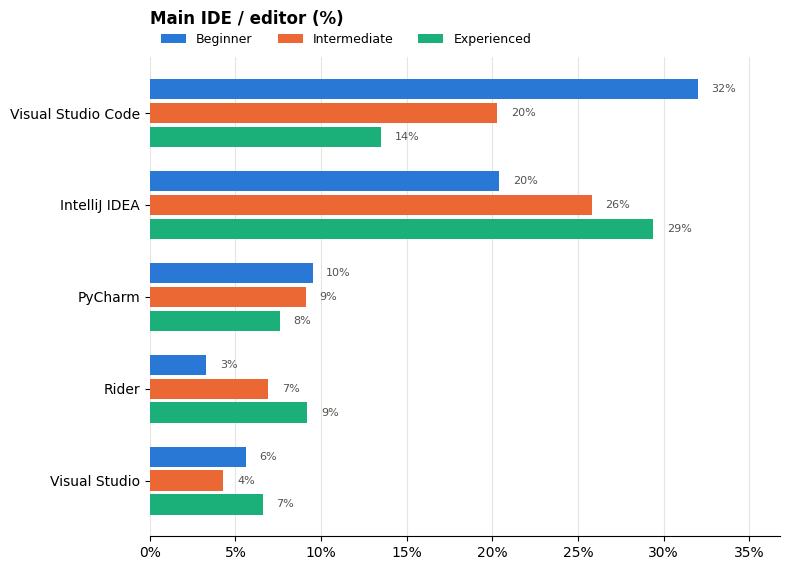

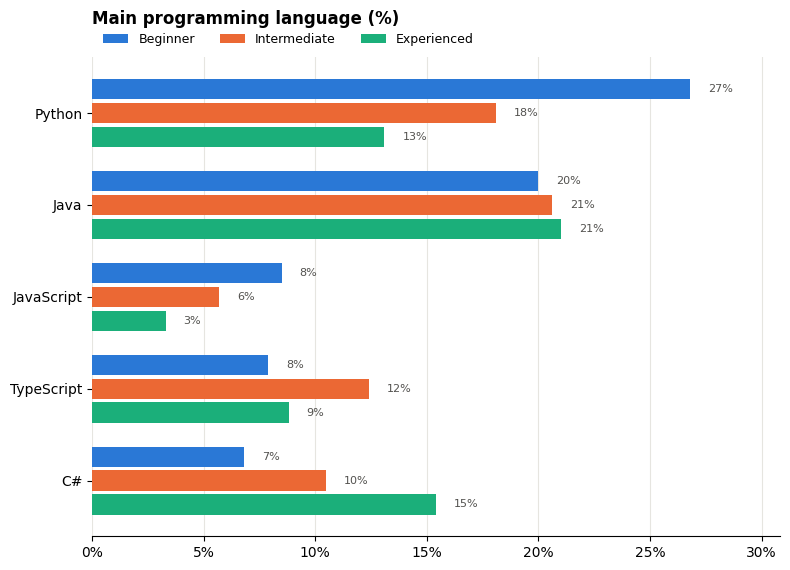

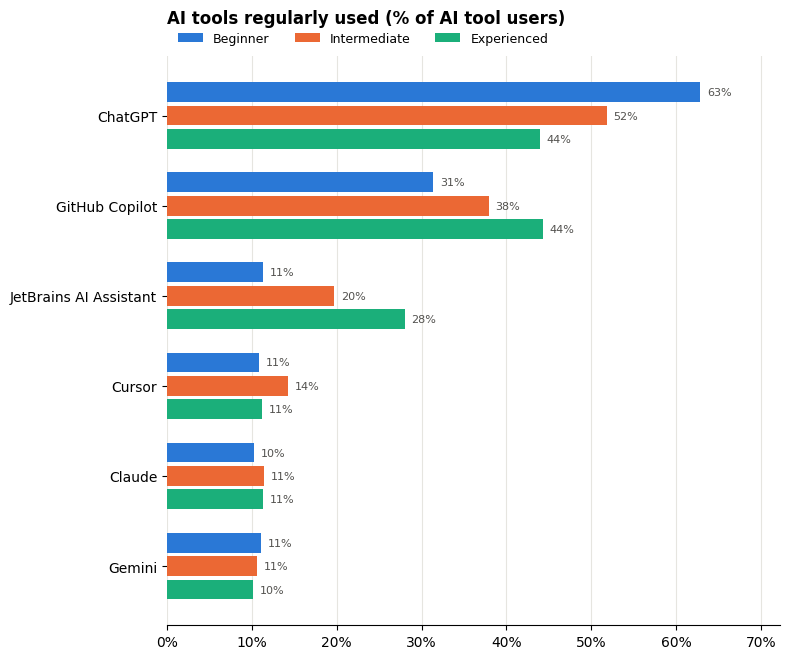

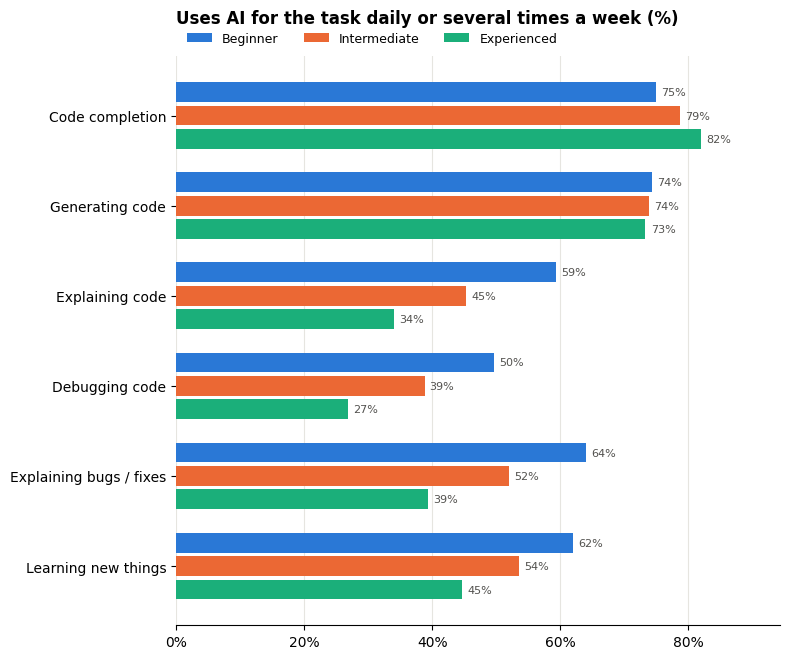

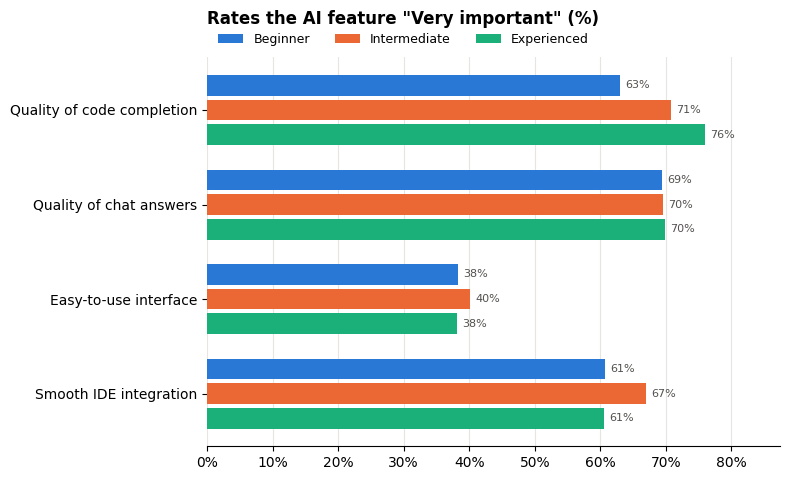

In [17]:
import matplotlib.pyplot as plt
import numpy as np

COLORS = {"Beginner": "#2a78d6", "Intermediate": "#eb6834", "Experienced": "#1baf7a"}

def bar_chart(title, table):
    labels = list(table.index)
    y = np.arange(len(labels))[::-1]
    h = 0.26
    fig, ax = plt.subplots(figsize=(8, 0.9 * len(labels) + 1.3))
    for k, g in enumerate(GROUPS):
        vals = table[g].values
        ax.barh(y + (1 - k) * h, vals, height=h - 0.04, color=COLORS[g], label=g)
        for v, yy in zip(vals, y + (1 - k) * h):
            ax.text(v + 0.8, yy, f"{v:.0f}%", va="center", fontsize=8, color="#52514e")
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlim(0, table[GROUPS].values.max() * 1.15)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.grid(axis="x", color="#e6e5e0")
    ax.set_axisbelow(True)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.set_title(title.split(". ", 1)[1], loc="left", fontweight="bold", pad=24)
    ax.legend(ncol=3, loc="lower left", bbox_to_anchor=(0, 1.0), frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()

for title in list(TABLES)[:5]:
    bar_chart(title, TABLES[title])

### Key findings

1.The groups differ most in why they use AI, not in whether they use it. About 80% of every group uses at least one AI tool.
There is a clear difference between beginners (0–2 years) and experienced developers (11+ years) in why they use AI.

2.Beginners use AI to understand code: 59% often use it to explain code (vs 34% of experienced developers), 64% to explain bugs (vs 39%) and 50% to debug (vs 27%).

3.Experienced developers use AI for speed: 82% often use AI code completion (vs 75%), and 76% rate completion quality "Very important" (vs 63%).

4.Beginners prefer chat tools like ChatGPT (63% vs 44%); Experienced developers prefer AI inside the IDE, like GitHub Copilot (44% vs 31%) and JetBrains AI Assistant (28% vs 11%).

5.Beginners use lighter editors (VS Code 32% vs 14%) and more often use AI to learn (62% vs 45%).

6.Most developers already use AI tools: about 80% of every group uses at least one.


### User profiles

- **Profile A: Beginner Learner.** 0–2 years, Python, lightweight editor (VS Code). Relies on AI to *explain* code, fix bugs and learn, mostly through chat (ChatGPT). Needs guidance, detailed errors and guided debugging.
- **Profile B: Experienced Professional.** 11+ years, Java/C#, full IDE (IntelliJ, Rider). Uses AI mainly for *code completion* through IDE-integrated tools (Copilot, JetBrains AI). Prefers minimal prompts, compact errors and fast completion.
- **Profile C: Intermediate Developer.** 3–10 years; sits between A and B on every measure.

## Construct the user model

In [18]:
# What each attribute tells the system, and the values it can take
ATTRIBUTES = {
    "experience_level":     (["Beginner", "Intermediate", "Experienced"], "How long the user has coded professionally."),
    "preferred_language":   (["Python", "Java"], "Which language the editor loads, checks and completes."),
    "editor_style":         (["Lightweight", "Full IDE"], "Simple editor or full IDE: changes toolbar, font size and status bar."),
    "guidance_level":       (["High", "Moderate", "Low"], "How much step-by-step help the user wants."),
    "error_detail":         (["Detailed", "Compact"], "Plain-language error explanations or short compiler-style lines."),
    "debugging_assistance": (["High", "Moderate", "Low"], "How much the system walks the user through fixing a bug."),
    "code_completion":      (["High", "Moderate", "Low"], "How eagerly the editor suggests completions."),
    "ai_assistance_mode":   (["Chat tutor", "Chat + inline", "Inline"], "Where AI help lives: a chat that explains, or suggestions in the editor."),
    "learning_support":     (["On", "Off"], "Whether to show short lessons about concepts in the code."),
}

USER_MODELS = {
    "Beginner Learner": {
        "experience_level": "Beginner",       # 0–2 years
        "preferred_language": "Python",       # Python 27% of Beginners
        "editor_style": "Lightweight",        # VS Code 32%
        "guidance_level": "High",             # explain code 59%
        "error_detail": "Detailed",           # explain bugs 64%
        "debugging_assistance": "High",       # debugging 50%
        "code_completion": "Moderate",        # completion "very important" 63%
        "ai_assistance_mode": "Chat tutor",   # ChatGPT 63%
        "learning_support": "On",             # learning 62%, 36% students
    },
    "Intermediate Developer": {
        "experience_level": "Intermediate",
        "preferred_language": "Java",
        "editor_style": "Full IDE",
        "guidance_level": "Moderate",
        "error_detail": "Detailed",
        "debugging_assistance": "Moderate",
        "code_completion": "High",
        "ai_assistance_mode": "Chat + inline",
        "learning_support": "On",
    },
    "Experienced Professional": {
        "experience_level": "Experienced",    # 11+ years
        "preferred_language": "Java",         # Java 21%, C# 15%
        "editor_style": "Full IDE",           # IntelliJ 29%
        "guidance_level": "Low",              # explain code 34%
        "error_detail": "Compact",            # explain bugs 39%
        "debugging_assistance": "Low",        # debugging 27%
        "code_completion": "High",            # completion "very important" 76%
        "ai_assistance_mode": "Inline",       # Copilot 44%, JetBrains AI 28%
        "learning_support": "Off",            # learning 45%
    },
}

model_table = pd.DataFrame(USER_MODELS)
model_table["What it tells the system"] = [ATTRIBUTES[a][1] for a in model_table.index]
display(model_table)

,Beginner Learner,Intermediate Developer,Experienced Professional,What it tells the system
experience_level,Beginner,Intermediate,Experienced,How long the user has coded professionally.
preferred_language,Python,Java,Java,"Which language the editor loads, checks and completes."
editor_style,Lightweight,Full IDE,Full IDE,"Simple editor or full IDE: changes toolbar, font size and status bar."
guidance_level,High,Moderate,Low,How much step-by-step help the user wants.
error_detail,Detailed,Detailed,Compact,Plain-language error explanations or short compiler-style lines.
debugging_assistance,High,Moderate,Low,How much the system walks the user through fixing a bug.
code_completion,Moderate,High,High,How eagerly the editor suggests completions.
ai_assistance_mode,Chat tutor,Chat + inline,Inline,"Where AI help lives: a chat that explains, or suggestions in the editor."
learning_support,On,On,Off,Whether to show short lessons about concepts in the code.


## Design the adaptation rules

In [19]:
# Each rule: attribute -> {value: behavior}, plus the evidence from Part 2 (Beginner / Intermediate / Experienced)
RULES = [
    ("guidance_level", {"High": "Show all hints as numbered steps + typing tips",
                        "Moderate": "Hints on request, one at a time",
                        "Low": "No hints"},
     "Use AI to explain code: 59% / 45% / 34%"),
    ("error_detail", {"Detailed": "Explain errors: what happened, how to fix, example",
                      "Compact": "One-line compiler-style errors"},
     "Use AI to explain bugs: 64% / 52% / 39%"),
    ("debugging_assistance", {"High": "Guided step-by-step debugging, then show the fix",
                              "Moderate": "Apply-fix button",
                              "Low": "Quick fix only"},
     "Use AI for debugging: 50% / 39% / 27%"),
    ("code_completion", {"High": "Suggest from the 1st letter, with snippets",
                         "Moderate": "Keyword suggestions after 3 letters",
                         "Low": "Only on Ctrl+Space"},
     "Completion quality 'very important': 63% / 71% / 76%"),
    ("ai_assistance_mode", {"Chat tutor": "AI tutor chat panel",
                            "Chat + inline": "Chat panel + AI suggestions in editor",
                            "Inline": "No chat; AI suggestions inside the editor"},
     "ChatGPT 63/52/44%; Copilot 31/38/44%; JetBrains AI 11/20/28%"),
    ("learning_support", {"On": "Show concept lessons", "Off": "Hide lessons"},
     "Use AI to learn: 62% / 54% / 45%"),
    ("editor_style", {"Lightweight": "Simple toolbar, larger font",
                      "Full IDE": "Compact toolbar, shortcuts, status bar"},
     "VS Code 32/20/14%; IntelliJ 20/26/29%"),
    ("preferred_language", {"Python": "Python task, checker and completions",
                            "Java": "Java task, checker and completions"},
     "Python 27/18/13%; Java 20/21/21%"),
]

def adapt(model):
    """Turn a user model into the system behavior (one line per rule)."""
    return {attr: effects[model[attr]] for attr, effects, _ in RULES}

rules_table = pd.DataFrame({name: adapt(m) for name, m in USER_MODELS.items()})
rules_table["Evidence (Beg / Int / Exp)"] = [ev for _, _, ev in RULES]
display(rules_table)

,Beginner Learner,Intermediate Developer,Experienced Professional,Evidence (Beg / Int / Exp)
guidance_level,Show all hints as numbered steps + typing tips,"Hints on request, one at a time",No hints,Use AI to explain code: 59% / 45% / 34%
error_detail,"Explain errors: what happened, how to fix, example","Explain errors: what happened, how to fix, example",One-line compiler-style errors,Use AI to explain bugs: 64% / 52% / 39%
debugging_assistance,"Guided step-by-step debugging, then show the fix",Apply-fix button,Quick fix only,Use AI for debugging: 50% / 39% / 27%
code_completion,Keyword suggestions after 3 letters,"Suggest from the 1st letter, with snippets","Suggest from the 1st letter, with snippets",Completion quality 'very important': 63% / 71% / 76%
ai_assistance_mode,AI tutor chat panel,Chat panel + AI suggestions in editor,No chat; AI suggestions inside the editor,ChatGPT 63/52/44%; Copilot 31/38/44%; JetBrains AI 11/20/28%
learning_support,Show concept lessons,Show concept lessons,Hide lessons,Use AI to learn: 62% / 54% / 45%
editor_style,"Simple toolbar, larger font","Compact toolbar, shortcuts, status bar","Compact toolbar, shortcuts, status bar",VS Code 32/20/14%; IntelliJ 20/26/29%
preferred_language,"Python task, checker and completions","Java task, checker and completions","Java task, checker and completions",Python 27/18/13%; Java 20/21/21%


###Adaptive Coding System Prototype: State of Developer Ecosystem Report 2025 HTML

In [50]:
from IPython.display import HTML, display

html_string = r'''
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Adaptive Coding System Prototype: State of Developer Ecosystem Report 2025</title>
<style>
  * { box-sizing: border-box; margin: 0; padding: 0; }
  body {
    font-family: 'Segoe UI', system-ui, sans-serif;
    background: #ffffff; color: #333333; padding: 16px; font-size: 14px; line-height: 1.5;
  }
  .app { max-width: 1100px; margin: 0 auto; border: 1px solid #dcd1f0; border-radius: 10px; overflow: hidden; background: #ffffff; box-shadow: 0 4px 15px rgba(0,0,0,0.05); }

  /* ---------- top bar ---------- */
  .topbar { display: flex; flex-wrap: wrap; gap: 12px; align-items: center; justify-content: space-between;
            padding: 12px 16px; background: #5c2d91; border-bottom: 1px solid #4a1e73; color: #ffffff; }
  .brand { font-weight: 600; font-size: 15px; color: #ffffff; }
  .brand span { color: #d0bdf4; font-weight: 400; font-size: 12.5px; margin-left: 8px; }
  .profiles { display: flex; gap: 6px; }
  .pbtn { border: 1px solid #d0bdf4; background: transparent; color: #ffffff; padding: 7px 14px;
          border-radius: 999px; cursor: pointer; font-size: 13px; font-weight: 500; }
  .pbtn .dot { display: inline-block; width: 8px; height: 8px; border-radius: 50%; margin-right: 7px; }
  .pbtn.active { color: #5c2d91; border-color: #ffffff; background: #ffffff; }
  .pbtn.a.active { font-weight: bold; }
  .pbtn.b.active { font-weight: bold; }

  /* ---------- layout ---------- */
  .main { display: grid; grid-template-columns: minmax(0, 1fr) 320px; }
  @media (max-width: 800px) { .main { grid-template-columns: 1fr; } }
  .left { border-right: 1px solid #f0e6ff; min-width: 0; background: #ffffff; }
  .label { font-size: 11px; text-transform: uppercase; letter-spacing: .08em; color: #7b2cbf; font-weight: 600; }

  /* task + hints */
  .task { padding: 12px 16px; border-bottom: 1px solid #f0e6ff; background: #fdfbfe; }
  .task p { color: #3c1642; font-size: 13.5px; margin-top: 4px; }
  .hints { margin-top: 10px; display: grid; gap: 6px; }
  .hint { background: #f5edfd; border: 1px solid #e0cffc; border-radius: 6px; padding: 7px 10px; font-size: 13px; color: #3c1642; }
  .hint b { color: #7b2cbf; margin-right: 6px; font-family: Consolas, monospace; font-size: 12px; }

  /* toolbar */
  .toolbar { display: flex; gap: 6px; flex-wrap: wrap; align-items: center; padding: 8px 12px; background: #f5f0fa; border-bottom: 1px solid #f0e6ff; }
  .tb { border: 1px solid #dcd1f0; background: #ffffff; color: #5c2d91; padding: 5px 12px; border-radius: 6px; cursor: pointer; font-size: 12.5px; }
  .tb:hover { background: #f2ebfa; }
  .tb.run { background: #7b2cbf; border-color: #7b2cbf; color: #ffffff; }
  .tb.run:hover { background: #6411ad; }
  .tb.ai { color: #ffffff; background: #9d4edd; border-color: #9d4edd; }
  .tb.ai:hover { background: #7b2cbf; }
  .file { margin-left: auto; font-family: Consolas, monospace; font-size: 12px; color: #7b2cbf; }

  /* editor */
  .editor { display: flex; background: #fcfbfe; border-bottom: 1px solid #f0e6ff; }
  .gutter { width: 42px; height: 180px; overflow: hidden; padding: 12px 8px 12px 0; text-align: right; color: #a393eb; font-family: Consolas, monospace;
            font-size: 13px; line-height: 1.6; user-select: none; border-right: 1px solid #f0e6ff; background: #f8f5fd; }
  .gutter div.err { color: #e63946; font-weight: 700; }
  textarea { flex: 1; min-width: 0; height: 180px; background: transparent; color: #240046; border: 0; outline: none; resize: vertical;
             padding: 12px; font-family: Consolas, 'Cascadia Code', monospace; font-size: 13px; line-height: 1.6;
             white-space: pre; tab-size: 4; }
  .suggest { padding: 7px 12px; border-top: 1px solid #f0e6ff; font-size: 12.5px; color: #7b2cbf; min-height: 34px; display: flex; gap: 6px; flex-wrap: wrap; align-items: center; background: #fdfbfe; }
  .chip { font-family: Consolas, monospace; font-size: 12px; padding: 2px 8px; border-radius: 5px; border: 1px solid #dcd1f0; background: #ffffff; color: #5c2d91; cursor: pointer; }
  .chip.ai { border-color: #9d4edd; color: #9d4edd; background: #fdf0ff; }

  /* problems */
  .problems { padding: 12px 16px; border-top: 1px solid #f0e6ff; min-height: 120px; background: #ffffff; }
  .ok { color: #2d6a4f; font-weight: 600; margin-top: 8px; }
  .err-line { font-family: Consolas, monospace; font-size: 13px; color: #e63946; padding: 6px 0; border-bottom: 1px dashed #f0e6ff; display: flex; gap: 10px; align-items: center; flex-wrap: wrap; }
  .card { margin-top: 10px; border: 1px solid #f8d7da; border-left: 4px solid #e63946; background: #fff5f5; border-radius: 6px; padding: 10px 12px; color: #721c24; }
  .card h4 { color: #c30010; font-size: 14px; margin-bottom: 4px; }
  .card p { font-size: 13px; margin: 3px 0; color: #5c2d91; }
  .card p b { color: #3c1642; font-weight: 600; }
  .card code, .mono { font-family: Consolas, monospace; background: #f2ebfa; padding: 1px 5px; border-radius: 4px; font-size: 12.5px; color: #5c2d91; }
  .steps { margin: 6px 0 0 18px; font-size: 13px; }
  .fixbtn { border: 1px solid #7b2cbf; background: #7b2cbf; color: #ffffff; padding: 3px 10px; border-radius: 5px; cursor: pointer; font-size: 12px; margin-top: 6px; }
  .fixbtn:hover { background: #6411ad; }

  /* right panel */
  .right { padding: 14px 16px; display: flex; flex-direction: column; gap: 16px; background: #fdfaff; border-left: 1px solid #f0e6ff; }
  .panel h3 { font-size: 14px; color: #3c1642; margin: 4px 0 8px; display: flex; justify-content: space-between; align-items: center; border-bottom: 2px solid #e0cffc; padding-bottom: 4px; }
  .sim { font-size: 10.5px; color: #9d4edd; border: 1px solid #d0bdf4; border-radius: 999px; padding: 1px 7px; font-weight: 500; background: #ffffff; }
  .aibtns { display: grid; grid-template-columns: 1fr 1fr; gap: 6px; }
  .aibtn { border: 1px solid #dcd1f0; background: #ffffff; color: #5c2d91; border-radius: 6px; padding: 8px; cursor: pointer; font-size: 12.5px; text-align: left; }
  .aibtn:hover { background: #f5edfd; border-color: #9d4edd; }
  .reply { margin-top: 10px; background: #f5edfd; border: 1px solid #e0cffc; border-radius: 8px; padding: 10px 12px; font-size: 13px; color: #3c1642; }
  .reply ul { margin: 6px 0 0 16px; }
  .reply pre { background: #ffffff; border: 1px solid #dcd1f0; padding: 8px; border-radius: 6px; font-family: Consolas, monospace; font-size: 12px; margin-top: 6px; overflow-x: auto; color: #5c2d91; }
  .lesson { background: #e8f5e9; border: 1px solid #c8e6c9; border-radius: 8px; padding: 10px 12px; font-size: 13px; color: #1b5e20; }
  .lesson b { color: #2e7d32; }

  .model .row { display: flex; justify-content: space-between; gap: 8px; padding: 5px 0; border-bottom: 1px solid #f0e6ff; font-size: 12.5px; }
  .model .row span { color: #7b2cbf; font-family: Consolas, monospace; font-size: 12px; }
  .model .row strong { color: #3c1642; font-weight: 600; }

  /* evidence strip */
  .evidence { border-top: 1px solid #dcd1f0; padding: 12px 16px 16px; background: #f5f0fa; }
  .ev-grid { display: grid; grid-template-columns: repeat(auto-fit, minmax(230px, 1fr)); gap: 8px; margin-top: 8px; }
  .ev { border: 1px solid #dcd1f0; border-radius: 8px; padding: 9px 11px; background: #ffffff; }
  .ev .rule { font-size: 12.5px; color: #3c1642; font-weight: 600; }
  .ev .why { font-size: 12px; color: #7b2cbf; margin-top: 2px; }
  .bars { margin-top: 6px; display: grid; gap: 3px; }
  .bar { display: grid; grid-template-columns: 78px 1fr 34px; gap: 6px; align-items: center; font-size: 11px; color: #5c2d91; }
  .track { height: 6px; background: #f0e6ff; border-radius: 3px; overflow: hidden; }
  .fill { height: 100%; border-radius: 3px; }
  .hidden { display: none !important; }
  footer { padding: 9px 16px; font-size: 11.5px; color: #7b2cbf; border-top: 1px solid #dcd1f0; background: #fdfbfe; }
  .gutter div { height: 1.6em; }
  .err-line .chip.ai { cursor: default; }
</style>
</head>
<body>
<div class="app" id="app">
  <div class="topbar">
    <div class="brand">Adaptive Coding System Prototype <span>State of Developer Ecosystem Report 2025 (n = 24,534)</span></div>
    <div class="profiles">
      <button class="pbtn a" id="btnA" onclick="setProfile('beginner')"><span class="dot" style="background:#d0bdf4"></span>Profile A · Beginner</button>
      <button class="pbtn b" id="btnB" onclick="setProfile('experienced')"><span class="dot" style="background:#9d4edd"></span>Profile B · Experienced</button>
    </div>
  </div>

  <div class="main">
    <div class="left">
      <div class="task">
        <div class="label">Task</div>
        <p>Write <span class="mono">average(scores)</span> that returns the average of a list, then print the average of [85, 92, 78]. The starter code has 2 bugs.</p>
        <div class="hints" id="hints"></div>
      </div>

      <div class="toolbar">
        <button class="tb run" onclick="runCheck()">Check code</button>
        <button class="tb ai" onclick="generate()">Generate code (AI)</button>
        <button class="tb" onclick="resetCode()">Reset</button>
        <span class="file">main.py</span>
      </div>

      <div class="editor">
        <div class="gutter" id="gutter"></div>
        <textarea id="editor" spellcheck="false" wrap="off"></textarea>
      </div>

      <div class="suggest" id="suggest"></div>

      <div class="problems">
        <div class="label" id="probTitle">Problems</div>
        <div id="problems"></div>
      </div>
    </div>

    <div class="right">
      <div class="panel model">
        <h3>Active User Model <span class="sim">Rule Engine</span></h3>
        <div class="row"><strong>Experience level</strong> <span id="m_exp"></span></div>
        <div class="row"><strong>Language</strong> <span id="m_lang"></span></div>
        <div class="row"><strong>Editor Style</strong> <span id="m_style"></span></div>
        <div class="row"><strong>Guidance Level</strong> <span id="m_guidance"></span></div>
        <div class="row"><strong>Error Detail</strong> <span id="m_error"></span></div>
        <div class="row"><strong>Debugging Assistance</strong> <span id="m_debug"></span></div>
        <div class="row"><strong>Code Completion</strong> <span id="m_completion"></span></div>
        <div class="row"><strong>AI assistance mode</strong> <span id="m_ai_mode"></span></div>
        <div class="row"><strong>Learning support</strong> <span id="m_learn"></span></div>
      </div>

      <div class="panel" id="chatPanel">
        <h3>AI Assistant <span class="sim">Chat Tutor</span></h3>
        <div class="aibtns">
          <button class="aibtn" onclick="askAI('explain')">Explain current code</button>
          <button class="aibtn" onclick="askAI('why')">Why is it wrong?</button>
          <button class="aibtn" onclick="askAI('fix')">How do I fix this?</button>
          <button class="aibtn" onclick="askAI('learn')">Teach me the concept</button>
        </div>
        <div id="aiReply" class="reply hidden"></div>
      </div>

      <div class="panel" id="inlinePanel">
        <h3>AI Assistant <span class="sim">Inline</span></h3>
        <div style="font-size:12.5px;color:#5c2d91">AI suggestions appear inside the editor and next to each error. No chat, fewer interruptions.</div>
      </div>

      <div class="panel" id="lessonPanel">
        <h3>Micro-Learning Concept</h3>
        <div class="lesson" id="lessonContent"></div>
      </div>
    </div>
  </div>

  <div class="evidence">
    <div class="label">Adaptation Evidence &amp; Signals (Beginner vs Experienced, from the survey)</div>
    <div class="ev-grid" id="evidence"></div>
  </div>
  <footer>The demo task is the same Python code for both profiles so the results can be compared. Only the assistance changes with the user model.</footer>
</div>

<script>
  // ================= USER MODELS (same values as Part 3 of the notebook) =================
  const PROFILES = {
    beginner: {
      exp: 'Beginner (0-2 yrs)', lang: 'Python', style: 'Lightweight', guidance: 'High',
      error: 'Detailed', debug: 'High', completion: 'Moderate', ai_mode: 'Chat tutor', learn: 'On'
    },
    experienced: {
      exp: 'Experienced (11+ yrs)', lang: 'Java', style: 'Full IDE', guidance: 'Low',
      error: 'Compact', debug: 'Low', completion: 'High', ai_mode: 'Inline', learn: 'Off'
    }
  };

  // ================= EVIDENCE (Beginner % vs Experienced %) =================
  const EVIDENCE = [
    { rule: 'Guidance & Tutorials',         why: 'Uses AI to explain code',         b: 59, e: 34 },
    { rule: 'Error Details',                why: 'Uses AI to explain bugs/fixes',   b: 64, e: 39 },
    { rule: 'Debugging Assistance',         why: 'Uses AI for debugging',           b: 50, e: 27 },
    { rule: 'Code Completion',              why: 'Rated feature "Very important"',  b: 63, e: 76 },
    { rule: 'AI Chat Tutor',                why: 'AI users who use ChatGPT',        b: 63, e: 44 },
    { rule: 'Inline AI in the IDE',         why: 'AI users who use GitHub Copilot', b: 31, e: 44 },
    { rule: 'Micro-Learning',               why: 'Uses AI to learn about coding',   b: 62, e: 45 },
    { rule: 'Generate Code (same for all)', why: 'Uses AI to generate code',        b: 74, e: 73 }
  ];

  const STARTER = "def average(scores)\n    total = 0\n    for s in scores:\n        total = total + s\n    return total / len(scores)\n\nscores = [85, 92, 78]\nprint(\"Average:\", average(scores)\n";
  const SOLUTION = "def average(scores):\n    total = 0\n    for s in scores:\n        total = total + s\n    return total / len(scores)\n\nscores = [85, 92, 78]\nprint(\"Average:\", average(scores))\n";
  const HINTS = [
    "Start the function with def average(scores): and keep the colon at the end.",
    "Inside the function, set total = 0, then add each score with a for loop.",
    "Return total / len(scores).",
    "Call the function and print the result. Every ( needs a matching )."
  ];
  const LINE_SUGGEST = [
    [/^\s*def/, "def average(scores):"], [/^\s*for/, "for s in scores:"], [/^\s*tot/, "total = total + s"],
    [/^\s*re/, "return total / len(scores)"], [/^\s*pri/, "print(\"Average:\", average(scores))"]
  ];
  const KEYWORDS = ["def", "return", "for", "while", "print", "len", "range", "total", "scores", "average"];

  let curProfile = 'beginner';
  let problems = [];
  let checked = false;
  const editor = document.getElementById('editor');
  const $ = id => document.getElementById(id);
  const esc = s => s.replace(/&/g, '&amp;').replace(/</g, '&lt;').replace(/"/g, '&quot;');
  const cfg = () => PROFILES[curProfile];

  // ================= ERROR CHECKER (checks every line) =================
  function check(code) {
    const out = [];
    code.split('\n').forEach((line, i) => {
      const t = line.trim();
      if (/^(def|if|elif|else|for|while|class)\b/.test(t) && !t.endsWith(':')) {
        out.push({ line: i + 1, col: line.length + 1, short: "SyntaxError: expected ':'", title: 'Missing Colon (:)',
          what: 'Lines that start a block (def, if, for, while) must end with a colon.',
          how: 'Add : at the end of the line.', fix: line.replace(/\s*$/, '') + ':' });
      }
      const open = (t.match(/\(/g) || []).length, close = (t.match(/\)/g) || []).length;
      if (open > close) {
        out.push({ line: i + 1, col: line.indexOf('(') + 1, short: "SyntaxError: '(' was never closed", title: 'Bracket Never Closed',
          what: 'Every opening bracket ( needs a closing bracket ).',
          how: 'Add ) at the end of the line.', fix: line.replace(/\s*$/, '') + ')'.repeat(open - close) });
      }
    });
    return out;
  }

  // ================= APPLY ADAPTATION =================
  function setProfile(p) {
    curProfile = p;
    $('btnA').classList.toggle('active', p === 'beginner');
    $('btnB').classList.toggle('active', p === 'experienced');
    const c = cfg();

    // Model display
    $('m_exp').innerText = c.exp; $('m_lang').innerText = c.lang; $('m_style').innerText = c.style;
    $('m_guidance').innerText = c.guidance; $('m_error').innerText = c.error; $('m_debug').innerText = c.debug;
    $('m_completion').innerText = c.completion; $('m_ai_mode').innerText = c.ai_mode; $('m_learn').innerText = c.learn;

    // Rule 1: guidance level -> hints
    $('hints').innerHTML = c.guidance === 'High'
      ? HINTS.map((h, i) => `<div class="hint"><b>Step ${i + 1}:</b> ${esc(h)}</div>`).join('') : '';

    // Rule 5: AI mode -> chat tutor or inline AI
    $('chatPanel').classList.toggle('hidden', c.ai_mode !== 'Chat tutor');
    $('inlinePanel').classList.toggle('hidden', c.ai_mode !== 'Inline');

    // Rule 6: learning support -> micro-lesson
    $('lessonPanel').classList.toggle('hidden', c.learn !== 'On');
    $('lessonContent').innerHTML = "<b>Function Definition (def):</b> In Python, functions are declared with the <code>def</code> keyword. They need parenthesized parameters and must end with a colon (<code>:</code>) to start the indented block.";

    // Rule 7: editor style -> bigger editor for lightweight users
    const h = c.style === 'Lightweight' ? '230px' : '180px', fs = c.style === 'Lightweight' ? '15px' : '13px';
    editor.style.height = h; editor.style.fontSize = fs;
    $('gutter').style.height = h; $('gutter').style.fontSize = fs;

    // Evidence strip
    $('evidence').innerHTML = EVIDENCE.map(ev => `
      <div class="ev"><div class="rule">${ev.rule}</div><div class="why">${ev.why}</div>
        <div class="bars">
          <div class="bar"><span>Beginner</span><div class="track"><div class="fill" style="width:${ev.b}%;background:#7b2cbf"></div></div><span>${ev.b}%</span></div>
          <div class="bar"><span>Experienced</span><div class="track"><div class="fill" style="width:${ev.e}%;background:#d0bdf4"></div></div><span>${ev.e}%</span></div>
        </div></div>`).join('');

    resetCode();
  }

  // ================= CHECK CODE (Rules 2 and 3) =================
  function runCheck() {
    problems = check(editor.value); checked = true;
    renderProblems(); updateGutter();
    if (cfg().ai_mode === 'Chat tutor' && problems.length) askAI('why');
  }

  function renderProblems() {
    const c = cfg(), box = $('problems');
    $('probTitle').innerText = c.error === 'Detailed' ? 'Problems explained' : 'Problems';
    if (!checked) { box.innerHTML = "<div style='color:#7b2cbf;margin-top:8px'>Press Check code to find errors.</div>"; return; }
    if (!problems.length) {
      box.innerHTML = c.error === 'Detailed'
        ? "<div class='ok'>✔ No errors. Great job! Output: Average: 85.0</div>"
        : "<div class='ok'>✔ 0 problems · Average: 85.0</div>";
      return;
    }
    if (c.error === 'Compact') {
      box.innerHTML = problems.map((p, i) => `<div class="err-line">${p.line}:${p.col} ${esc(p.short)}
        <button class="fixbtn" onclick="applyFix(${i})">Quick fix</button>
        ${c.ai_mode === 'Inline' ? `<span class="chip ai">AI: ${esc(p.fix.trim())}</span>` : ''}</div>`).join('');
    } else {
      box.innerHTML = problems.map((p, i) => `<div class="card">
        <h4>Line ${p.line}: ${p.title}</h4>
        <p><b>Your code:</b> <code>${esc(editor.value.split('\n')[p.line - 1].trim())}</code></p>
        <p><b>What happened:</b> ${p.what}</p>
        <p><b>How to fix:</b> ${p.how}</p>
        ${c.debug === 'High'
          ? `<ol class="steps"><li>Go to line ${p.line}.</li><li>Compare it with the hint steps above.</li><li>Try to fix it yourself, then press Check code.</li></ol>
             <button class="fixbtn" onclick="showFix(${i}, this)">Still stuck? Show the fixed line</button>`
          : `<button class="fixbtn" onclick="applyFix(${i})">Apply fix</button>`}
      </div>`).join('');
    }
  }
  function showFix(i, btn) {
    btn.outerHTML = `<p><b>Fixed line:</b> <code>${esc(problems[i].fix.trim())}</code></p><button class="fixbtn" onclick="applyFix(${i})">Apply this fix</button>`;
  }
  function applyFix(i) {
    const lines = editor.value.split('\n');
    lines[problems[i].line - 1] = problems[i].fix;
    editor.value = lines.join('\n');
    runCheck(); renderSuggest();
  }

  // ================= CODE COMPLETION (Rule 4) =================
  let pendingLine = '';
  function renderSuggest() {
    const c = cfg(), code = editor.value, pos = editor.selectionStart;
    const lineText = code.slice(code.lastIndexOf('\n', pos - 1) + 1, pos);
    const word = (lineText.match(/[A-Za-z_]+$/) || [''])[0];
    const chips = [];
    pendingLine = '';
    if (c.completion === 'High' && lineText.trim().length >= 2) {
      const hit = LINE_SUGGEST.find(([re]) => re.test(lineText));
      if (hit) { pendingLine = hit[1]; chips.push(`<span class="chip ai" onclick="acceptLine()">AI: ${esc(hit[1])}</span>`); }
    }
    const minLen = c.completion === 'High' ? 1 : 3;
    if (word.length >= minLen) KEYWORDS.filter(k => k.startsWith(word) && k !== word).slice(0, 4)
      .forEach(k => chips.push(`<span class="chip" onclick="acceptWord('${k}','${word}')">${k}</span>`));
    $('suggest').innerHTML = chips.length ? 'Suggestions: ' + chips.join('')
      : (c.completion === 'High' ? 'Full-line AI suggestions appear as you type' : 'Keyword suggestions appear after 3 letters');
  }
  function acceptWord(k, w) {
    const p = editor.selectionStart;
    editor.value = editor.value.slice(0, p - w.length) + k + editor.value.slice(p);
    editor.focus(); editor.selectionStart = editor.selectionEnd = p - w.length + k.length;
    onType();
  }
  function acceptLine() {
    const p = editor.selectionStart, start = editor.value.lastIndexOf('\n', p - 1) + 1;
    let end = editor.value.indexOf('\n', p); if (end < 0) end = editor.value.length;
    const indent = editor.value.slice(start, end).match(/^\s*/)[0];
    editor.value = editor.value.slice(0, start) + indent + pendingLine + editor.value.slice(end);
    editor.focus(); onType();
  }

  // ================= AI CHAT TUTOR (Rule 5) =================
  function askAI(type) {
    const reply = $('aiReply'), errs = check(editor.value);
    let html = '';
    if (type === 'explain') {
      html = "<b>AI Assistant:</b> Here is what your code does:<ul>" +
        "<li><code>def average(scores)</code> creates a function that takes a list.</li>" +
        "<li><code>total = 0</code> starts a running total.</li>" +
        "<li><code>for s in scores:</code> adds each score to the total.</li>" +
        "<li><code>return total / len(scores)</code> divides by the number of scores.</li>" +
        "<li><code>print(...)</code> shows the average on the screen.</li></ul>";
    } else if (type === 'why') {
      html = errs.length
        ? `<b>AI Assistant:</b> I found ${errs.length} problem${errs.length > 1 ? 's' : ''}:<ul>` + errs.map(e => `<li>Line ${e.line}: ${e.title}. ${e.what}</li>`).join('') + '</ul>Try fixing the first one yourself!'
        : '<b>AI Assistant:</b> No errors found. Your program prints Average: 85.0.';
    } else if (type === 'fix') {
      html = errs.length ? `<b>AI Assistant:</b> Look at line ${errs[0].line}. ${errs[0].how}` : '<b>AI Assistant:</b> Nothing to fix. Your code works.';
    } else {
      html = "<b>AI Assistant:</b> A <b>for loop</b> runs the same lines once for every item in a list.<pre>for name in [\"Ana\", \"Ben\"]:\n    print(\"Hi\", name)</pre>";
    }
    reply.innerHTML = html; reply.classList.remove('hidden');
  }

  // ================= SAME FOR EVERYONE =================
  function generate() { editor.value = SOLUTION; checked = false; problems = []; onType(); renderProblems(); }
  function resetCode() { editor.value = STARTER; checked = false; problems = []; $('aiReply').classList.add('hidden'); onType(); renderProblems(); }

  function updateGutter() {
    const n = editor.value.split('\n').length, bad = new Set(checked ? problems.map(p => p.line) : []);
    $('gutter').innerHTML = Array.from({ length: n }, (_, i) => `<div class="${bad.has(i + 1) ? 'err' : ''}">${i + 1}</div>`).join('');
  }
  function onType() {
    if (checked) { problems = check(editor.value); renderProblems(); }
    updateGutter(); renderSuggest();
  }

  editor.addEventListener('input', onType);
  editor.addEventListener('click', renderSuggest);
  editor.addEventListener('keyup', renderSuggest);
  editor.addEventListener('scroll', () => { $('gutter').scrollTop = editor.scrollTop; });

  setProfile('beginner');
</script>
</body>
</html>
'''

display(HTML(html_string))